# --------------------------------------------------
# Author: Haotian Xiao, Kateřina Škardová, Charline Dubois
# Institution : Laboratoire LMS, École Polytechnique, Laboratoire de Chimie et de la Matière Condensée de Paris 
# Created: April 2025
# --------------------------------------------------

In [1]:
from hexalattice.hexalattice import create_hex_grid
import numpy as np
import meshio
import matplotlib.pyplot as plt
import time
from tqdm.auto import tqdm
import os
from collections import deque
from numba import jit

output_folder = "simulation_results"
os.makedirs(output_folder, exist_ok=True)

# Parameters for the hexagonal grid
nx, ny = 25, 40  # Number of hexagons in the x and y directions
dx = 1           # Distance between centers of hexagons

# Create hexagonal grid
hex_centers, hex_grid = create_hex_grid(nx=nx, ny=ny, do_plot=False, min_diam=dx)

def get_hex_vertices(center):
    # Get vertices of hexagon with given center
    radius = 2/np.sqrt(3)*dx/2
    angles = np.linspace(0, 2 * np.pi, 7)[:-1]  # 6 vertices
    vertices = np.column_stack((center[0] + radius * np.cos(angles + np.pi/2),
                                center[1] + radius * np.sin(angles + np.pi/2)))
    return vertices

# Collect all vertices in the grid
hex_vertices_list = []
for center in hex_centers:
    hex_vertices_list.append(get_hex_vertices(center))
hex_vertices_array = np.vstack(hex_vertices_list)

# Ensure unique vertices and reshape cells
unique_vertices, indices = np.unique(hex_vertices_array.round(decimals=6), axis=0, return_inverse=True)
hex_cells = np.reshape(indices, (-1, 6))

# Define unique edges
unique_edges = []
for hexagon in hex_cells:
    for i in range(len(hexagon)):
        node1 = hexagon[i]
        node2 = hexagon[(i + 1) % len(hexagon)]  
        edge = tuple(sorted((node1, node2)))  
        if edge not in unique_edges:
            unique_edges.append(edge)

# Identify boundary nodes and edges
point_ids = np.arange(len(unique_vertices))
boundary_id = np.zeros(len(unique_vertices))

boundary_l, boundary_r, boundary_t, boundary_b = [], [], [], []
for i in point_ids:
    idx = np.where(hex_cells == i)
    if (1 in idx[1] and 5 not in idx[1]) or (2 in idx[1] and 4 not in idx[1]):
        boundary_l.append(i)
    if (5 in idx[1] and 1 not in idx[1]) or (4 in idx[1] and 2 not in idx[1]):
        boundary_r.append(i)
    if (0 in idx[1] and 2 not in idx[1] and 4 not in idx[1]) or (1 in idx[1] and 3 not in idx[1] and 5 in idx[1]):
        boundary_t.append(i)
    if (3 in idx[1] and 1 not in idx[1] and 5 not in idx[1]) or (4 in idx[1] and 0 not in idx[1] and 2 in idx[1]):
        boundary_b.append(i)

boundary_id[np.unique(boundary_t)] = 1
boundary_id[np.unique(boundary_b)] = 2
boundary_id[np.unique(boundary_l)] = 3
boundary_id[np.unique(boundary_r)] = 4

# Identify edges on/connected to boundary
boundary_status = np.zeros(len(unique_edges))
for e in range(len(unique_edges)):
    node1, node2 = unique_edges[e]
    if boundary_id[node1] > 0 and boundary_id[node2] > 0:
        boundary_status[e] = 2
    elif (boundary_id[node1] > 0 and boundary_id[node2] == 0) or (boundary_id[node1] == 0 and boundary_id[node2] > 0):
        boundary_status[e] = 1

# Export to VTK
points = unique_vertices
mesh = meshio.Mesh(points, [("line", unique_edges)], point_data={'Boundary_nodes': boundary_id}, cell_data={'Boundary_edges': [boundary_status]})

output_file_edge = os.path.join(output_folder, "hexagonal_mesh_EDGE.vtk")
meshio.write(output_file_edge, mesh)


#############################################################################
#Constant that may change base on Suki's paper
# Agent-related constants
At = 10.0         # Fibrotic threshold for cross-sectional area
A0 = 1            # Initial cross-sectional area
epsilon_s = 1.0   # Target strain
beta = 3.0        # Steepness for stiffness Hill function
gamma = 1.0       # Steepness for strain Hill function
w1, w2 = 1, 1.0 # Weights for strain and stiffness contributions
c = 0.5*w1 + w2*(A0 / At) ** beta / ((A0 / At) ** beta + 1)
r = 1.0             # Memory factor
P = 0.2           # Scaling constant for spring constant update
p1 = 0.01         # Probability of new Agent appearing
D_0 = 0.3          # Initial agent density
Dmax = 3
##############################################################################



# Initialize Agent Parameters
num_springs = len(unique_edges)
epsilon = np.ones(num_springs)   # Initial strain for each spring
a = np.zeros(num_springs)         # Initial activation level for each spring
D = np.full(num_springs, 0.3)     # Initial agent density for each spring


Warning: VTK requires 3D points, but 2D points given. Appending 0 third component.

In [2]:
def identify_regions(spring_constants, k_fibrosis, k_normal):
    """
    Identify which springs are inside the stiffened region and which are on the edge.
    Returns two boolean arrays: inside_region, edge_region.
    """
    inside_region = np.zeros(len(spring_constants), dtype=bool)
    edge_region = np.zeros(len(spring_constants), dtype=bool)
    
    # Iterate over each spring
    for spring_index, k_value in enumerate(spring_constants):
        # Identify neighbors of the current spring
        nodes = edges[spring_index]
        connected = np.where((nodes[0] == edges[:, 0]) | 
                             (nodes[0] == edges[:, 1]) | 
                             (nodes[1] == edges[:, 0]) | 
                             (nodes[1] == edges[:, 1]))[0]
        
        neighbor_stiffness = spring_constants[connected]
        
        # If all neighbors are stiff, the spring is inside the stiffened region
        if np.all(neighbor_stiffness >= 30):
            inside_region[spring_index] = True
        # If some neighbors are stiff and some are normal, it's on the edge
        elif np.any(neighbor_stiffness >= 30) and np.any(neighbor_stiffness == 30):
            edge_region[spring_index] = True
    
    return inside_region, edge_region

def compute_strain_and_stress(points, edges, l0, spring_constants):
    """
    Compute strain and stress for each spring based on the current positions.
    Returns two arrays: strain and stress.
    """
    strain = np.zeros(len(edges))
    stress = np.zeros(len(edges))

    for i, edge in enumerate(edges):
        node1, node2 = edge
        p1, p2 = points[node1], points[node2]

        # Calculate current length of the spring
        current_length = np.linalg.norm(p2 - p1)
        
        # Calculate strain and stress
        strain[i] = (current_length - l0) / l0
        stress[i] = spring_constants[i] * strain[i]

    return strain, stress


def compute_spring_force(p1, p2, l0, k):
    current_length = np.linalg.norm(p2 - p1)
    displacement = current_length - l0
    force_magnitude = k * displacement  # Force magnitude based on spring constant

    direction = (p2 - p1) / current_length
    force = force_magnitude * direction
    return force

# Calculate forces on each node from all connected springs
@jit(nopython=True)
def compute_total_forces_numba(forces_on_nodes, points, edges, l0, spring_constants):
    forces_on_nodes[:] = 0  # Reset forces to zero at each iteration
    for i in range(len(edges)):
        node1, node2 = edges[i]
        p1, p2 = points[node1], points[node2]

        # Compute force directly without additional function call
        current_length = np.linalg.norm(p2 - p1)
        displacement = current_length - l0
        force_magnitude = spring_constants[i] * displacement
        direction = (p2 - p1) / current_length

        force = force_magnitude * direction

        forces_on_nodes[node1] += force
        forces_on_nodes[node2] -= force  # Opposite force on node2

@jit(nopython=True)
def move_nodes_numba(points, forces_on_nodes, mu, free_nodes):
    for i in free_nodes[0]:  # Iterate only over free nodes
        points[i] += mu * forces_on_nodes[i]

@jit(nopython=True)
def compute_total_energy_numba(points, edges, l0, spring_constants):
    total_energy = 0.0
    for i in range(len(edges)):
        node1, node2 = edges[i]
        p1, p2 = points[node1], points[node2]

        # Calculate energy directly
        current_length = np.linalg.norm(p2 - p1)
        displacement = current_length - l0
        energy = 0.5 * spring_constants[i] * displacement ** 2
        total_energy += energy
    return total_energy

# Remove specified edges and corresponding spring constants
def remove_edge(edges, points, spring_constants, removed_id):
    point_ids = np.arange(len(points))
    
    # Step 1: Remove edges that should be removed
    for i in removed_id:
        edges = np.delete(edges, i, axis=0)
        spring_constants = np.delete(spring_constants, i, axis=0)

    # Step 2: Remove edges that have become disconnected after Step 1
    for i in point_ids:
        idx = np.where(edges == i)
        n_of_edges = len(idx[0])

        if n_of_edges==1:
            edges = np.delete(edges, idx[0], axis=0)
            spring_constants = np.delete(spring_constants, idx[0], axis=0)

    return edges, spring_constants

# # # # # # # # # # # # # # # # # # # # # # # # # # # # # #

# Functions for agent-specific updates
# Stiffness-based activation
# Parameters for softening phase


# Functions for agent-specific updates

# Stiffness-based activation
def calc_aK(A, At, beta):
    return (A / At) ** beta / ((A / At) ** beta + 1)

# Strain-based activation
def calc_aepsilon(epsilon, epsilon_s, gamma):
    return (epsilon / epsilon_s) ** gamma / ((epsilon / epsilon_s) ** gamma + 1)

# Update the activation with memory effect
def update_activation(a, a_epsilon, a_K, w1, w2, c, r):
    return a * (1 - r) + r * (w1 * a_epsilon + w2 * a_K - c)

# Update agent density
def update_agent_density(D, a, p1, n, s, D_0, Dmax, w2):
    X = Dmax / D_0
    p2 = p1 * n / (s * D_0)
    p3 = (p2 * (1 - (1 / X))) / (w2 - 0.5)
    return D + (p1 * n / s) + (p3 * a - p2) * D

def calculate_spring_constants(areas, young_modulus, l0):
    """Calculate spring constants based on area and Young's modulus."""
    return (young_modulus * areas) #/ l0

##########################################################################################################
#KEY functions to test !!!
def update_modulus_and_area(E, A, spring_constants, a, D, P_modulus, P_area, soften_triggered, soften_duration, recovery_rate, E_baseline, one_time_triggered):
    """
    Update Young's modulus (E) with individual softening and recovery behavior that triggers only once,
    and update area (A) directly based on agent activation.
    """
    new_E = E.copy()
    new_A = A.copy()
    
    for i in range(len(a)):
        # Check if stiffness exceeds threshold to trigger softening for E (only if not triggered before)
        if spring_constants[i] > 5 and not one_time_triggered[i]:
            soften_triggered[i] = True
            one_time_triggered[i] = True  # Mark as triggered once permanently

        # Update area A directly based on agent activation
        new_A[i] += P_area * a[i] * D[i]  # Adjust A continuously based on agent effect

    return new_A , new_E


# Update spring constants with a softening phase followed by normal behavior
def update_spring_constant(spring_constants, a, D, P, phase):
    new_spring_constants = spring_constants.copy()
    
    for i in range(len(a)):
        if phase < softening_duration:
            # Apply softening during the initial phase
            new_spring_constants[i] += P * a[i] * D[i]
            #softened_stiffness = spring_constants[i] * (1 - softening_factor * a[i] * D[i])
        else:
            # Normal behavior after softening phase: no further modification
            new_spring_constants[i] += P * a[i] * D[i]
        
        # Optional: Update history with new stiffness value
        spring_history[i].append(new_spring_constants[i])
    
    return new_spring_constants

######################################################################################################


def plot_energy(energy):

    plt.plot(energy)

    plt.xlabel("Number of iterations")
    plt.ylabel("Total energy")

    plt.show()
    plt.clf()

In [3]:
def simulate(points, edges, l0, spring_constants, mu, T, tolerance, max_iterations, free_nodes, plot_bar=True, print_results=False, energy_plot=True):
    if plot_bar:
        progress_bar = tqdm(total=max_iterations, desc="Simulation Progress")

    iteration = 0
    previous_energy = compute_total_energy_numba(points, edges, l0, spring_constants)
    delta_energy = 10
    stagnation_counter = 0
    stagnation = False

    # Set up tracking for energy
    energy = [] if energy_plot else None
    forces_on_nodes = np.zeros_like(points)  # Initialize forces array

    while iteration < max_iterations and not stagnation:
        # In-place force calculation
        compute_total_forces_numba(forces_on_nodes, points, edges, l0, spring_constants)

        temp_points = points.copy()
        # In-place node movement
        move_nodes_numba(temp_points, forces_on_nodes, mu, free_nodes)

        # In-place energy calculation
        new_energy = compute_total_energy_numba(temp_points, edges, l0, spring_constants)

        if energy_plot:
            energy.append(new_energy)

        delta_energy = new_energy - previous_energy
        relative_energy_change = abs(delta_energy) / abs(new_energy)
        stagnation_counter = stagnation_counter + 1 if relative_energy_change < tolerance else 0
        stagnation = stagnation_counter >= 20

        # Acceptance criteria
        if delta_energy < 0:
            previous_energy = new_energy
            points = temp_points
            mu *= 1.1
            P = 0
        else:
            P = np.exp(-delta_energy / T)
            if np.random.random() < P:
                previous_energy = new_energy
                points = temp_points
            else:
                mu *= 0.9  # Reject configuration

        T *= 0.99
        iteration += 1
        if plot_bar:
            progress_bar.update(1)

        if print_results and (iteration == 1 or iteration % 250 == 0):
            print(f"Iteration {iteration}, mu: {mu}, T: {T}, P = {P}")
            print(f"New energy: {new_energy}")
            print("Energy change:", delta_energy)
            print("Number of edges:", len(edges))

    if energy_plot:
        plot_energy(energy)

    return points, edges, spring_constants

Simulation Progress:   0%|          | 0/2000 [00:00<?, ?it/s]

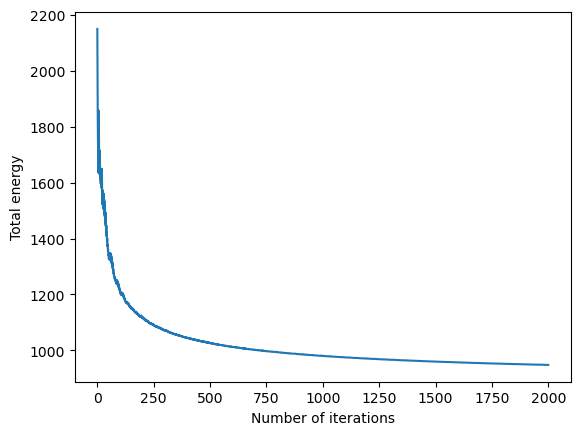

Warning: VTK requires 3D points, but 2D points given. Appending 0 third component.

<Figure size 640x480 with 0 Axes>

In [4]:
# Load the mesh with edges
mesh_path = "simulation_results/hexagonal_mesh_EDGE.vtk"  # Specify the path to the mesh file
mesh_EDGE = meshio.read(mesh_path)  # Load edges from VTK file

# Extract the points (coordinates) and edges (line cells)
points = mesh_EDGE.points[:, :2]  # Use only x, y coordinates for 2D mesh
edges = mesh_EDGE.cells_dict['line']  # Get line elements representing edges

# Boundary identification
boundary_node_ids = mesh_EDGE.point_data['Boundary_nodes']
boundary_edge_ids = mesh_EDGE.cell_data['Boundary_edges'][0]


################################################################################################
#Constants to test
# Simulation parameters
k_normal = 1.0             # Normal spring constant for healthy springs
k_fibrosis = 50 * k_normal  # Increased stiffness for fibrotic springs
dx = 1.0                    # Initial distance factor (ensure you update this as needed)
l0 = 0.6 * (2 / np.sqrt(3) * dx / 2)  # Rest length for the springs
mu = 0.01                   # Initial step size for nodal movement
T = 1.0                     # Initial temperature for simulated annealing
alpha = 0.6                # Proportion of springs that will become fibrotic
max_iterations = 1200        # Maximum iterations for each convergence cycle
tolerance = 1e-7            # Tolerance for convergence based on relative energy change
walk_length = 300           # Length of the random walk for fibrosis spread
soften_rate = 1             # Softening rate for agents in specific regions
P_modulus = 0.0005


softening_factor = 0.05    # Factor to reduce stiffness during the softening phase
################################################################################################

# Initialize a history tracking list for each spring (optional)
history_length = 10       # Number of past values to keep for each spring

# Set initial spring constants
E_initial = 1.0  # Set baseline Young's modulus value
young_modulus = np.full(len(edges), E_initial) 
spring_constants = np.full(len(edges), k_normal)  # All springs start with normal stiffness
spring_history = [deque([k], maxlen=history_length) for k in spring_constants]  # Stiffness history
# Free nodes (not on boundary)
free_nodes = np.where(boundary_node_ids == 0)

soften_triggered = np.zeros(len(spring_constants), dtype=bool)  # Track if softening has been triggered
soften_duration = np.full(len(spring_constants), 150)  # Duration of softening for each spring
#soften_duration = i*[0]  # Duration of softening for each spring
recovery_rate = 0.003  # Rate at which E recovers after softening
E_baseline = 1.0  # Target baseline value for E

# Run the random walk for fibrosis initialization
healthy_ids = np.where((spring_constants == k_normal))[0]
while len(healthy_ids) / len(edges) > 1 - alpha:
    feasible_ids = np.where(spring_constants == k_normal)[0]
    #feasible_ids = np.where((spring_constants==k_normal)&(boundary_edge_ids == 1 ))[0]
    #len(feasible_ids) 
    #print(len(feasible_ids)) #check car peur d'un ensemble vide
    new_stiff = np.random.choice(feasible_ids)
    spring_constants[new_stiff] = k_fibrosis

    # Do random walk (spread fibrosis)
    for i in range(walk_length):
        nodes = edges[new_stiff]
        connected = np.where(
            (nodes[0] == edges[:, 0]) | (nodes[0] == edges[:, 1]) | (nodes[1] == edges[:, 0]) | (nodes[1] == edges[:, 1])
        )
        new_stiff = np.random.choice(connected[0])
        spring_constants[new_stiff] = k_fibrosis

    # Update
    healthy_ids = np.where((spring_constants == k_normal))[0]

# Pre-converge step
points = np.asarray(points, dtype=np.float64)
edges = np.asarray(edges, dtype=np.int32)
spring_constants = np.asarray(spring_constants, dtype=np.float64)

pre_convergence_iterations = 2000
final_positions, final_edges, final_spring_constants = simulate(points, edges, l0, spring_constants, mu, T, tolerance, pre_convergence_iterations, free_nodes
)

points = final_positions
edges = final_edges
spring_constants = final_spring_constants
A = spring_constants
strain, stress = compute_strain_and_stress(final_positions, edges, l0, spring_constants)
filename = os.path.join(output_folder, "hexagonal_mesh_final_result_EDGE_init.vtk")
meshio.write(
    filename,
    meshio.Mesh(
        final_positions,
        cells=[("line", final_edges)],
        cell_data={
            "Stiffness": [spring_constants],
            "Strain": [strain],
            "Stress": [stress]
        }
    )
)


In [5]:
# Simulation with agent
# Specify the output folder and filename
output_folder = "simulation_results"
filename = os.path.join(output_folder, "hexagonal_mesh_final_result_EDGE_init.vtk")

# Load the mesh from the initial file
mesh = meshio.read(filename)
points = mesh.points[:, :2]  # Extract x, y coordinates for 2D
edges = mesh.cells_dict["line"]  # Extract edges from the loaded mesh

# Extract any initial spring constants, if available; otherwise, initialize
try:
    spring_constants = mesh.cell_data["Stiffness"][0]
except KeyError:
    k_normal = 1.0  # Default spring constant
    spring_constants = np.full(len(edges), k_normal)



# Simulation with agent
print("Agent-based simulation")
agent_update_interval = 1500  #this means how many steps to solve each iteration, the more you have the less error you get
agent_total_iterations = 600  # Total iterations in agent-driven phase ; this means how many iterations for the agent based simulation 
activation_history = []
agent_density_history = []
stiffness_history = []
epsilon_history = []
stress_history = []
E_history = []

one_time_triggered = np.zeros(len(spring_constants), dtype=bool)

for phase in range(0, agent_total_iterations):
    
    # Update the agent density and activation here based on the new state of the system
    #epsilon = (A0*epsilon_s)/spring_constants # + epsilon (I'm not sure about this)
    epsilon, stress = compute_strain_and_stress(points, edges, l0, spring_constants)

    a_K = calc_aK(spring_constants, At, beta)
    a_epsilon = calc_aepsilon(epsilon, epsilon_s, gamma)
    a = update_activation(a, a_epsilon, a_K, w1, w2, c, r)

    #inside_region, edge_region = identify_regions(spring_constants, k_fibrosis, k_normal)
    A, young_modulus = update_modulus_and_area(
        young_modulus, A, spring_constants, a, D, P_modulus, P, soften_triggered, soften_duration, recovery_rate, E_baseline,one_time_triggered
    )

    #spring_constants = update_spring_constant(spring_constants, a, D, P, phase)
    spring_constants = calculate_spring_constants(A, young_modulus, l0)

    D = update_agent_density(D, a, p1, len(points), len(edges), D_0, Dmax, w2)
    D = np.clip(D, D_0, Dmax)  # Bound the agent density

    # Track the mean activation and agent density for plotting
    activation_history.append(np.mean(a))
    agent_density_history.append(np.mean(D))
    stiffness_history.append(np.mean(spring_constants))
    epsilon_history.append(np.mean(epsilon))
    stress_history.append(np.mean(stress))
    E_history.append(np.mean(young_modulus))
    
    # Run the simulation for the interval period
    points = np.asarray(points, dtype=np.float64)
    edges = np.asarray(edges, dtype=np.int32)
    spring_constants = np.asarray(spring_constants, dtype=np.float64)
    final_positions, edges, spring_constants = simulate(
        points, edges, l0, spring_constants, mu, T, tolerance, agent_update_interval, free_nodes, False, False, False)
    
    strain, stress = compute_strain_and_stress(final_positions, edges, l0, spring_constants)
    # Update points based on new positions
    points = final_positions

    # Save output every second phase
    if phase % 2 == 0:  # this means how many step we save a vtk file for output
        print(f"Phase: {phase}, D max: {np.max(D)}, Mean Stiffness: {np.mean(spring_constants)}")
        filename = os.path.join(output_folder, f"hexagonal_mesh_final_result_EDGE_agent_{str(phase).zfill(4)}.vtk")
        meshio.write(
            filename,
            meshio.Mesh(
                final_positions,
                cells=[("line", final_edges)],
                cell_data={
                    "Stiffness": [spring_constants],
                    "Strain": [strain],
                    "Stress": [stress],
                    "E": [young_modulus],
                    "A": [A]
                }
            )
        )

# Final mesh output
filename = os.path.join(output_folder, "hexagonal_mesh_final_result_EDGE.vtk")
meshio.write(
    filename,
    meshio.Mesh(
        final_positions,
        cells=[("line", final_edges)],
        cell_data={
            "Stiffness": [spring_constants],
            "Strain": [strain],
            "Stress": [stress]
        }
    )
)


Agent-based simulation
Phase: 0, D max: 0.31227980410786715, Mean Stiffness: 31.016548695465875


Warning: VTK requires 3D points, but 2D points given. Appending 0 third component.

Phase: 2, D max: 0.33731839907549704, Mean Stiffness: 31.074144462795985


Warning: VTK requires 3D points, but 2D points given. Appending 0 third component.

Phase: 4, D max: 0.3631514467810431, Mean Stiffness: 31.134821010777916


...

Phase: 596, D max: 3.0, Mean Stiffness: 197.02874204574013


Warning: VTK requires 3D points, but 2D points given. Appending 0 third component.

Phase: 598, D max: 3.0, Mean Stiffness: 197.8758811312828


Warning: VTK requires 3D points, but 2D points given. Appending 0 third component.

Warning: VTK requires 3D points, but 2D points given. Appending 0 third component.

# --------------------------------------------------
# Author: Haotian Xiao, Kateřina Škardová, Charline Dubois
# Institution : Laboratoire LMS, École Polytechnique, Laboratoire de Chimie et de la Matière Condensée de Paris 
# Created: April 2025
# --------------------------------------------------